In [1]:
# Cell 1 - Setup
import os
import numpy as np
import pandas as pd
from IPython.display import display

# The five inputs are expected at the project root; if not found there, fall back to
# data/scaleup/gold/ (where the flat tables were originally written). Pure path resolution
# only - all metric logic below is recomputed from the raw parquet files.
def _resolve(fname):
    for base in ('', 'data/scaleup/gold/', 'data/scaleup/silver/'):
        if os.path.exists(base + fname):
            return base + fname
    raise FileNotFoundError(f'could not find {fname} at project root or data/scaleup/gold/')

FILES = [
    ('flat_table1_responses.parquet',          'one row per response'),
    ('flat_table2_sentences.parquet',          'one row per sentence'),
    ('flat_table3_citations.parquet',          'one row per cited source per response'),
    ('flat_table4_entailment_scores.parquet',  'one row per (sentence, citation) pair'),
    ('nli_scaleup_cleaned.parquet',            'cleaned gold, one row per response'),
]
loaded = {}
for fname, desc in FILES:
    path = _resolve(fname)
    df = pd.read_parquet(path)
    loaded[fname] = df
    print(f'{fname}  ({desc})')
    print(f'   loaded from : {path}')
    print(f'   shape       : {df.shape}')
    print(f'   columns     : {list(df.columns)}')
    print()

t1      = loaded['flat_table1_responses.parquet']
t2      = loaded['flat_table2_sentences.parquet']
t3      = loaded['flat_table3_citations.parquet']
t4      = loaded['flat_table4_entailment_scores.parquet']
cleaned = loaded['nli_scaleup_cleaned.parquet']

# the cleaned gold file is keyed by engine/query_id/run_index; rebuild the same response_id
# string the flat tables use, so pawc_norm can be looked up by response_id in Cell 4.
cleaned['response_id'] = cleaned['engine'] + '__' + cleaned['query_id'] + '__r' + cleaned['run_index'].astype(str)
print('Added response_id (engine__query_id__rN) to the cleaned gold frame for later lookup.')

flat_table1_responses.parquet  (one row per response)
   loaded from : data/scaleup/gold/flat_table1_responses.parquet
   shape       : (9992, 13)
   columns     : ['response_id', 'query_id', 'engine', 'run_index', 'model_served', 'n_sentences', 'n_artifacts', 'cleaned_n', 'n_sources_cited', 'n_sources_fetched_ok', 'cleaned_ais', 'cleaned_pawc_total', 'pawc_norm']

flat_table2_sentences.parquet  (one row per sentence)
   loaded from : data/scaleup/gold/flat_table2_sentences.parquet
   shape       : (219897, 8)
   columns     : ['response_id', 'sentence_idx', 'sentence_text', 'word_count', 'position_weight', 'is_supported', 'is_artifact', 'n_supporting_sources']

flat_table3_citations.parquet  (one row per cited source per response)
   loaded from : data/scaleup/gold/flat_table3_citations.parquet
   shape       : (58851, 5)
   columns     : ['response_id', 'citation_position', 'url_canonical', 'domain', 'fetch_status']

flat_table4_entailment_scores.parquet  (one row per (sentence, cita

nli_scaleup_cleaned.parquet  (cleaned gold, one row per response)
   loaded from : data/scaleup/gold/nli_scaleup_cleaned.parquet
   shape       : (9992, 20)
   columns     : ['n_sentences', 'n_sources_cited', 'n_sources_fetched_ok', 'ais_supported_sentences', 'ais_rate', 'sentence_detail', 'pawc_by_source_position', 'pawc_total', 'nli_evaluations', 'input_tokens', 'output_tokens', 'engine', 'query_id', 'run_index', 'n_response_words', 'n_artifacts', 'cleaned_n', 'cleaned_ais', 'cleaned_pawc_total', 'pawc_norm']

Added response_id (engine__query_id__rN) to the cleaned gold frame for later lookup.


In [2]:
# Cell 2 - Pick one example response
# Criteria: >= 6 sentences total; >= 1 artefact sentence; >= 1 citation fetched OK;
#           >= 1 entailment score >= 0.5. Choose the first qualifying response_id when sorted
#           (deterministic, so the whole notebook is reproducible).
g          = t2.groupby('response_id')
n_sent_by  = g.size()
n_art_by   = g['is_artifact'].sum()
has_ok_cit = set(t3.loc[t3['fetch_status'] == 'ok', 'response_id'])
has_ent    = set(t4.loc[t4['entail_score'] >= 0.5, 'response_id'])

candidates = sorted(
    rid for rid in n_sent_by.index
    if n_sent_by[rid] >= 6 and n_art_by[rid] >= 1 and rid in has_ok_cit and rid in has_ent
)
print(f'{len(candidates)} responses satisfy all four criteria; choosing the first when sorted.')
RID = candidates[0]
print('Chosen response_id:', RID)

# full sentence table for this response (text truncated to 60 chars for display)
sent = t2[t2['response_id'] == RID].sort_values('sentence_idx').reset_index(drop=True)
sent_view = sent[['sentence_idx', 'sentence_text', 'word_count', 'position_weight', 'is_artifact']].copy()
sent_view['sentence_text'] = sent_view['sentence_text'].str.slice(0, 60)
print('\nSentence table (sentence_text truncated to 60 chars):')
display(sent_view)

# citation rows for this response
cit = t3[t3['response_id'] == RID].sort_values('citation_position').reset_index(drop=True)
print('\nCitation rows:')
display(cit)

# entailment rows for this response, with the binary entails flag
ent = (t4[t4['response_id'] == RID]
       .sort_values(['sentence_idx', 'citation_position']).reset_index(drop=True).copy())
ent['entails'] = (ent['entail_score'] >= 0.5).astype(int)
print('\nEntailment rows (entails = 1 if entail_score >= 0.5, else 0):')
display(ent)

4476 responses satisfy all four criteria; choosing the first when sorted.
Chosen response_id: chatgpt__gb_05912ccf2a3c68f8__r4

Sentence table (sentence_text truncated to 60 chars):


,sentence_idx,sentence_text,word_count,position_weight,is_artifact
0,1,"You have a few good options, depending on whet...",44,1.0000,False
1,2,You can search “birthday cake” and see what’s ...,12,0.9091,False
2,3,([instacart.com](https://www.instacart.com/sto...,27,0.8182,False
3,4,([wholefoodsmarket.com](https://www.wholefoods...,14,0.7273,False
4,5,Good if you don’t need same-day delivery.,7,0.6364,False
5,6,([goldbelly.com](https://www.goldbelly.com/col...,17,0.5455,False
6,7,([bakemeawish.com](https://www.bakemeawish.com...,18,0.4545,False
7,8,([shop.carlosbakery.com](https://shop.carlosba...,22,0.3636,False
8,9,### Quick recommendation\nIf you need it **tod...,16,0.2727,True
9,10,If you want something more memorable and can w...,21,0.1818,False



Citation rows:


,response_id,citation_position,url_canonical,domain,fetch_status
0,chatgpt__gb_05912ccf2a3c68f8__r4,1,https://www.instacart.com/store/s?k=birthday+c...,instacart.com,ok
1,chatgpt__gb_05912ccf2a3c68f8__r4,2,https://www.wholefoodsmarket.com/departments/b...,wholefoodsmarket.com,ok
2,chatgpt__gb_05912ccf2a3c68f8__r4,3,https://www.goldbelly.com/collections/best-bir...,goldbelly.com,http_403
3,chatgpt__gb_05912ccf2a3c68f8__r4,4,https://www.bakemeawish.com/,bakemeawish.com,ok
4,chatgpt__gb_05912ccf2a3c68f8__r4,5,https://shop.carlosbakery.com/,shop.carlosbakery.com,connection_error



Entailment rows (entails = 1 if entail_score >= 0.5, else 0):


,response_id,sentence_idx,citation_position,entail_score,entails
0,chatgpt__gb_05912ccf2a3c68f8__r4,1,1,0.60446,1
1,chatgpt__gb_05912ccf2a3c68f8__r4,1,2,0.50956,1
2,chatgpt__gb_05912ccf2a3c68f8__r4,1,4,0.42580,0
3,chatgpt__gb_05912ccf2a3c68f8__r4,2,1,0.99739,1
4,chatgpt__gb_05912ccf2a3c68f8__r4,2,2,0.16848,0
5,chatgpt__gb_05912ccf2a3c68f8__r4,2,4,0.98990,1
6,chatgpt__gb_05912ccf2a3c68f8__r4,3,1,0.06650,0
7,chatgpt__gb_05912ccf2a3c68f8__r4,3,2,0.56549,1
8,chatgpt__gb_05912ccf2a3c68f8__r4,3,4,0.41894,0
9,chatgpt__gb_05912ccf2a3c68f8__r4,4,1,0.12658,0


In [3]:
# Cell 3 - Andre's method, step by step (uses ALL sentences incl. artefacts;
#          denominator uses ALL cited sources regardless of fetch_status)
print("=== ANDRE'S METHOD ===\n")

# Step 1: w_len = position_weight x word_count for EVERY sentence (incl. artefacts)
andre = sent.copy()
andre['w_len'] = andre['position_weight'] * andre['word_count']
print('Step 1 - w_len = position_weight x word_count (every sentence, artefacts included):')
display(andre[['sentence_idx', 'sentence_text', 'word_count', 'position_weight', 'is_artifact', 'w_len']]
        .assign(sentence_text=lambda d: d['sentence_text'].str.slice(0, 60)))

# Step 2: omega = sum of w_len across all sentences
omega = andre['w_len'].sum()
print(f'\nStep 2 - omega = sum(w_len) over ALL sentences = {omega:.4f}')

# Step 3: n_citations = number of cited sources, regardless of fetch_status
n_citations = int((t3['response_id'] == RID).sum())
print(f'\nStep 3 - n_citations (all cited, any fetch_status) = {n_citations}')

# Step 4: merge entailment rows with w_len; pawc_term = w_len x entails
andre_merge = ent.merge(andre[['sentence_idx', 'w_len', 'is_artifact']], on='sentence_idx', how='left')
andre_merge['pawc_term'] = andre_merge['w_len'] * andre_merge['entails']
print('\nStep 4 - entailment rows merged with w_len; pawc_term = w_len x entails:')
display(andre_merge[['sentence_idx', 'citation_position', 'entail_score', 'entails', 'is_artifact', 'w_len', 'pawc_term']])

# Step 5: A = sum of pawc_term over all (sentence, citation) pairs
A_andre = andre_merge['pawc_term'].sum()
print(f'\nStep 5 - A = sum(pawc_term) over all (sentence, citation) pairs = {A_andre:.4f}')

# Step 6: B = n_citations x omega
B_andre = n_citations * omega
print(f'\nStep 6 - B = n_citations x omega = {n_citations} x {omega:.4f} = {B_andre:.4f}')

# Step 7: NORMALIZED_PAWC_ANDRE = A / B
NORMALIZED_PAWC_ANDRE = A_andre / B_andre
print(f'\nStep 7 - NORMALIZED_PAWC_ANDRE = A / B = {A_andre:.4f} / {B_andre:.4f} = {NORMALIZED_PAWC_ANDRE:.6f}')

=== ANDRE'S METHOD ===

Step 1 - w_len = position_weight x word_count (every sentence, artefacts included):


,sentence_idx,sentence_text,word_count,position_weight,is_artifact,w_len
0,1,"You have a few good options, depending on whet...",44,1.0000,False,44.0000
1,2,You can search “birthday cake” and see what’s ...,12,0.9091,False,10.9092
2,3,([instacart.com](https://www.instacart.com/sto...,27,0.8182,False,22.0914
3,4,([wholefoodsmarket.com](https://www.wholefoods...,14,0.7273,False,10.1822
4,5,Good if you don’t need same-day delivery.,7,0.6364,False,4.4548
5,6,([goldbelly.com](https://www.goldbelly.com/col...,17,0.5455,False,9.2735
6,7,([bakemeawish.com](https://www.bakemeawish.com...,18,0.4545,False,8.1810
7,8,([shop.carlosbakery.com](https://shop.carlosba...,22,0.3636,False,7.9992
8,9,### Quick recommendation\nIf you need it **tod...,16,0.2727,True,4.3632
9,10,If you want something more memorable and can w...,21,0.1818,False,3.8178



Step 2 - omega = sum(w_len) over ALL sentences = 127.2721

Step 3 - n_citations (all cited, any fetch_status) = 5

Step 4 - entailment rows merged with w_len; pawc_term = w_len x entails:


,sentence_idx,citation_position,entail_score,entails,is_artifact,w_len,pawc_term
0,1,1,0.60446,1,False,44.0000,44.0000
1,1,2,0.50956,1,False,44.0000,44.0000
2,1,4,0.42580,0,False,44.0000,0.0000
3,2,1,0.99739,1,False,10.9092,10.9092
4,2,2,0.16848,0,False,10.9092,0.0000
5,2,4,0.98990,1,False,10.9092,10.9092
6,3,1,0.06650,0,False,22.0914,0.0000
7,3,2,0.56549,1,False,22.0914,22.0914
8,3,4,0.41894,0,False,22.0914,0.0000
9,4,1,0.12658,0,False,10.1822,0.0000



Step 5 - A = sum(pawc_term) over all (sentence, citation) pairs = 158.6378

Step 6 - B = n_citations x omega = 5 x 127.2721 = 636.3605

Step 7 - NORMALIZED_PAWC_ANDRE = A / B = 158.6378 / 636.3605 = 0.249289


In [4]:
# Cell 4 - My method, step by step (artefacts removed; position weights recomputed over
#          survivors; denominator uses only fetched-OK citations)
print("=== MY METHOD ===\n")

# Step 1: keep non-artefact sentences only; show what was removed vs retained
removed   = sent[sent['is_artifact']].copy()
survivors = sent[~sent['is_artifact']].sort_values('sentence_idx').reset_index(drop=True).copy()
print('Step 1 - artefact sentences REMOVED:')
display(removed[['sentence_idx', 'sentence_text', 'word_count', 'is_artifact']]
        .assign(sentence_text=lambda d: d['sentence_text'].str.slice(0, 60)))
print('Surviving (non-artefact) sentences RETAINED:')
display(survivors[['sentence_idx', 'sentence_text', 'word_count', 'is_artifact']]
        .assign(sentence_text=lambda d: d['sentence_text'].str.slice(0, 60)))

# Step 2: recompute position weights from scratch over survivors via linear decay (N-k+1)/N,
#         k = 1-indexed rank in survivor order; then w_len = recomputed weight x word_count
N = len(survivors)
survivors['rank_k'] = np.arange(1, N + 1)
survivors['position_weight_cleaned'] = (N - survivors['rank_k'] + 1) / N
survivors['w_len'] = survivors['position_weight_cleaned'] * survivors['word_count']
print(f'\nStep 2 - recomputed survivor weights (N = {N}) and w_len:')
display(survivors[['sentence_idx', 'sentence_text', 'word_count', 'rank_k', 'position_weight_cleaned', 'w_len']]
        .assign(sentence_text=lambda d: d['sentence_text'].str.slice(0, 60)))

# Step 3: Omega_cleaned = sum of w_len over survivors
Omega_cleaned = survivors['w_len'].sum()
print(f'\nStep 3 - Omega_cleaned = sum(w_len) over survivors = {Omega_cleaned:.4f}')

# Step 4: M = citations with fetch_status == 'ok'
M = int(((t3['response_id'] == RID) & (t3['fetch_status'] == 'ok')).sum())
print(f'\nStep 4 - M = citations with fetch_status == "ok" = {M}')

# Step 5: merge entailment rows with the SURVIVOR sentences only (inner join drops artefact rows)
my_merge = ent.merge(survivors[['sentence_idx', 'w_len']], on='sentence_idx', how='inner')
my_merge['pawc_term'] = my_merge['w_len'] * my_merge['entails']
print('\nStep 5 - entailment rows merged with SURVIVOR w_len only; pawc_term = w_len x entails:')
display(my_merge[['sentence_idx', 'citation_position', 'entail_score', 'entails', 'w_len', 'pawc_term']])

# Step 6: A_cleaned = sum of pawc_term
A_cleaned = my_merge['pawc_term'].sum()
print(f'\nStep 6 - A_cleaned = sum(pawc_term) over survivor pairs = {A_cleaned:.4f}')

# Step 7: pawc_norm_manual = A_cleaned / (M x Omega_cleaned)
pawc_norm_manual = A_cleaned / (M * Omega_cleaned)
print(f'\nStep 7 - pawc_norm_manual = A_cleaned / (M x Omega_cleaned) '
      f'= {A_cleaned:.4f} / ({M} x {Omega_cleaned:.4f}) = {pawc_norm_manual:.6f}')

# Step 8: compare against the stored pawc_norm from the cleaned gold file
stored_pawc_norm = cleaned.loc[cleaned['response_id'] == RID, 'pawc_norm'].iloc[0]
diff = abs(pawc_norm_manual - stored_pawc_norm)
print(f'\nStep 8 - verification against stored pawc_norm:')
print(f'         stored pawc_norm  = {stored_pawc_norm:.6f}')
print(f'         pawc_norm_manual  = {pawc_norm_manual:.6f}')
print(f'         abs difference    = {diff:.2e}  ->  {"MATCH" if diff < 1e-6 else "DISCREPANCY"}')

=== MY METHOD ===

Step 1 - artefact sentences REMOVED:


,sentence_idx,sentence_text,word_count,is_artifact
8,9,### Quick recommendation\nIf you need it **tod...,16,True


Surviving (non-artefact) sentences RETAINED:


,sentence_idx,sentence_text,word_count,is_artifact
0,1,"You have a few good options, depending on whet...",44,False
1,2,You can search “birthday cake” and see what’s ...,12,False
2,3,([instacart.com](https://www.instacart.com/sto...,27,False
3,4,([wholefoodsmarket.com](https://www.wholefoods...,14,False
4,5,Good if you don’t need same-day delivery.,7,False
5,6,([goldbelly.com](https://www.goldbelly.com/col...,17,False
6,7,([bakemeawish.com](https://www.bakemeawish.com...,18,False
7,8,([shop.carlosbakery.com](https://shop.carlosba...,22,False
8,10,If you want something more memorable and can w...,21,False
9,11,If you tell me the **delivery city/ZIP code** ...,22,False



Step 2 - recomputed survivor weights (N = 10) and w_len:


,sentence_idx,sentence_text,word_count,rank_k,position_weight_cleaned,w_len
0,1,"You have a few good options, depending on whet...",44,1,1.0,44.0
1,2,You can search “birthday cake” and see what’s ...,12,2,0.9,10.8
2,3,([instacart.com](https://www.instacart.com/sto...,27,3,0.8,21.6
3,4,([wholefoodsmarket.com](https://www.wholefoods...,14,4,0.7,9.8
4,5,Good if you don’t need same-day delivery.,7,5,0.6,4.2
5,6,([goldbelly.com](https://www.goldbelly.com/col...,17,6,0.5,8.5
6,7,([bakemeawish.com](https://www.bakemeawish.com...,18,7,0.4,7.2
7,8,([shop.carlosbakery.com](https://shop.carlosba...,22,8,0.3,6.6
8,10,If you want something more memorable and can w...,21,9,0.2,4.2
9,11,If you tell me the **delivery city/ZIP code** ...,22,10,0.1,2.2



Step 3 - Omega_cleaned = sum(w_len) over survivors = 119.1000

Step 4 - M = citations with fetch_status == "ok" = 3

Step 5 - entailment rows merged with SURVIVOR w_len only; pawc_term = w_len x entails:


,sentence_idx,citation_position,entail_score,entails,w_len,pawc_term
0,1,1,0.60446,1,44.0,44.0
1,1,2,0.50956,1,44.0,44.0
2,1,4,0.42580,0,44.0,0.0
3,2,1,0.99739,1,10.8,10.8
4,2,2,0.16848,0,10.8,0.0
5,2,4,0.98990,1,10.8,10.8
6,3,1,0.06650,0,21.6,0.0
7,3,2,0.56549,1,21.6,21.6
8,3,4,0.41894,0,21.6,0.0
9,4,1,0.12658,0,9.8,0.0



Step 6 - A_cleaned = sum(pawc_term) over survivor pairs = 155.4000

Step 7 - pawc_norm_manual = A_cleaned / (M x Omega_cleaned) = 155.4000 / (3 x 119.1000) = 0.434929

Step 8 - verification against stored pawc_norm:
         stored pawc_norm  = 0.434929
         pawc_norm_manual  = 0.434929
         abs difference    = 1.11e-16  ->  MATCH


In [5]:
# Cell 5 - Side-by-side comparison
summary = pd.DataFrame([
    {'method': "Andre (uncleaned)",
     'omega used': round(omega, 4),
     'M / n_citations': n_citations,
     'A (numerator)': round(A_andre, 4),
     'denominator': round(B_andre, 4),
     'PAWC_norm': round(NORMALIZED_PAWC_ANDRE, 6)},
    {'method': "Mine (cleaned)",
     'omega used': round(Omega_cleaned, 4),
     'M / n_citations': M,
     'A (numerator)': round(A_cleaned, 4),
     'denominator': round(M * Omega_cleaned, 4),
     'PAWC_norm': round(pawc_norm_manual, 6)},
])
print(f'Side-by-side comparison for {RID}:')
display(summary)

Side-by-side comparison for chatgpt__gb_05912ccf2a3c68f8__r4:


,method,omega used,M / n_citations,A (numerator),denominator,PAWC_norm
0,Andre (uncleaned),127.2721,5,158.6378,636.3605,0.249289
1,Mine (cleaned),119.1000,3,155.4000,357.3000,0.434929


### Why the two values differ for `chatgpt__gb_05912ccf2a3c68f8__r4`

Both methods start from the **same entailment evidence**, so their numerators are almost identical (Andre `A = 158.64`, mine `A = 155.40`). The gap in the final score — **Andre 0.2493 vs mine 0.4349** — comes almost entirely from **what each method divides by**.

**1. Failed-fetch citations inflate Andre's denominator (the dominant effect).**
This response cited **5** sources, but only **3** were fetched successfully:

| position | domain | fetch_status |
|---|---|---|
| 1 | instacart.com | ok |
| 2 | wholefoodsmarket.com | ok |
| 3 | goldbelly.com | **http_403** |
| 4 | bakemeawish.com | ok |
| 5 | shop.carlosbakery.com | **connection_error** |

Andre divides by `n_citations = 5`; I divide by `M = 3`. The two failed sources (goldbelly, carlosbakery) returned **no text at all**, so they had zero chance of entailing any sentence — yet Andre's denominator still charges the response for them. Concretely, Andre's denominator is `5 × 127.27 = 636.36`, whereas mine is `3 × 119.10 = 357.30`. Dividing a near-identical numerator by a denominator that is ~1.8× larger is what roughly halves Andre's score.

**2. The artefact sentence is kept by Andre but removed by me (secondary effect).**
Sentence 9 — `"### Quick recommendation … If you need it today or tomorrow…"` — is a Markdown heading fragment, not an attributable claim. Andre keeps it, so it adds to his `omega` (127.27 over all 11 sentences); I drop it and re-index the surviving **10** sentences with fresh linear-decay weights, giving `Omega_cleaned = 119.10`. Because that header was essentially unsupported, removing it barely moves the numerator (158.64 → 155.40) but it does lower the omega each method uses.

**Net effect.** With near-equal numerators, the result is set by the denominator. Andre's denominator is inflated mainly by the two **un-fetchable citations** (and secondarily by the retained **artefact header**), so his normalised PAWC (0.2493) lands at roughly half of the cleaned value (0.4349). The cleaned method only credits and only divides by sources that actually produced text and sentences that are genuine claims, which is why it matches the stored `pawc_norm` exactly.

In [6]:
# Cell 6 - Unit test: decompose the denominator gap
def test_denominator_decomposition():
    # three intermediate denominators, each isolating one component
    B_fix_citations = M * omega                  # fix citation count only (keep artefact-inclusive omega)
    B_fix_artefacts = n_citations * Omega_cleaned  # fix omega only (keep all citations)
    B_both_fixed    = round(M * Omega_cleaned, 9) # both fixed -> the cleaned denominator (9-dp to avoid float dust)
    print(f'B_andre (no fixes)                 = {B_andre:.4f}')
    print(f'B_fix_citations  (M x omega)       = {B_fix_citations:.4f}')
    print(f'B_fix_artefacts  (n_cit x Omega)   = {B_fix_artefacts:.4f}')
    print(f'B_both_fixed     (M x Omega_clean) = {B_both_fixed:.4f}')

    # reductions when each component is fixed independently, measured from the full Andre denominator
    red_citations = B_andre - B_fix_citations
    red_artefacts = B_andre - B_fix_artefacts
    total_red     = B_andre - B_both_fixed
    interaction   = (n_citations - M) * (omega - Omega_cleaned)   # overlap of the two independent fixes
    print(f'reduction from fixing citations    = {red_citations:.4f}')
    print(f'reduction from fixing artefacts    = {red_artefacts:.4f}')
    print(f'total reduction (both fixed)       = {total_red:.4f}')
    print(f'sum of individual reductions       = {red_citations + red_artefacts:.4f}')
    print(f'interaction term                   = {interaction:.4f}')

    # assertions
    assert abs(B_both_fixed - M * Omega_cleaned) < 1e-9, 'B_both_fixed must equal M * Omega_cleaned'
    assert B_both_fixed == round(M * Omega_cleaned, 9), 'B_both_fixed must equal round(M * Omega_cleaned, 9)'
    # the two independent fixes double-count their overlap, so their sum exceeds the true total
    # reduction by exactly the interaction term; verify that identity to within 1e-4
    assert abs((red_citations + red_artefacts) - (total_red + interaction)) < 1e-4, \
        'sum of individual reductions must equal total reduction plus the interaction term'
    print('PASS')

test_denominator_decomposition()

B_andre (no fixes)                 = 636.3605
B_fix_citations  (M x omega)       = 381.8163
B_fix_artefacts  (n_cit x Omega)   = 595.5000
B_both_fixed     (M x Omega_clean) = 357.3000
reduction from fixing citations    = 254.5442
reduction from fixing artefacts    = 40.8605
total reduction (both fixed)       = 279.0605
sum of individual reductions       = 295.4047
interaction term                   = 16.3442
PASS


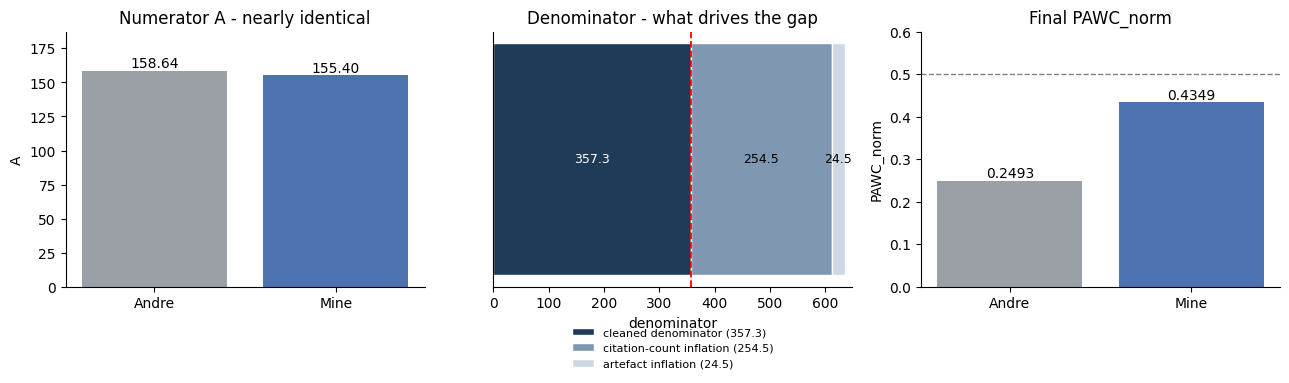

denominator gap (Andre - cleaned) = 279.0605
  failed-fetch citations: 91.2%
  artefact retention:     8.8%


In [7]:
# Cell 7 - Three-panel figure (matplotlib only)
%matplotlib inline
import os
import matplotlib.pyplot as plt

# the Cell 6 components are function-local; recompute the ones the figure needs from in-scope vars
B_fix_citations    = M * omega
B_both_fixed       = M * Omega_cleaned
citation_inflation = B_andre - B_fix_citations       # gap from counting un-fetched citations
artefact_inflation = B_fix_citations - B_both_fixed  # gap from retaining the artefact in omega

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel 1 - numerators (nearly identical)
ax = axes[0]
bars = ax.bar(['Andre', 'Mine'], [A_andre, A_cleaned], color=['#9aa0a6', '#4C72B0'])
for b, v in zip(bars, [A_andre, A_cleaned]):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.2f}', ha='center', va='bottom')
ax.set_ylim(0, A_andre * 1.18)
ax.set_ylabel('A')
ax.set_title('Numerator A - nearly identical')

# Panel 2 - stacked horizontal denominator decomposition
ax = axes[1]
segments = [('cleaned denominator', B_both_fixed,       '#1f3b57'),   # darkest
            ('citation-count inflation', citation_inflation, '#7f97b0'),  # medium
            ('artefact inflation', artefact_inflation, '#cdd8e4')]    # lightest
left = 0.0
for label, val, color in segments:
    ax.barh(0, val, left=left, color=color, edgecolor='white', label=f'{label} ({val:.1f})')
    ax.text(left + val / 2, 0, f'{val:.1f}', ha='center', va='center', fontsize=9,
            color='white' if color == '#1f3b57' else 'black')
    left += val
ax.axvline(B_both_fixed, color='red', linestyle='--', linewidth=1.3)  # cleaned-denominator marker
ax.set_yticks([])
ax.set_xlim(0, B_andre * 1.02)
ax.set_xlabel('denominator')
ax.set_title('Denominator - what drives the gap')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), frameon=False, fontsize=8, ncol=1)

# Panel 3 - final PAWC_norm
ax = axes[2]
bars = ax.bar(['Andre', 'Mine'], [NORMALIZED_PAWC_ANDRE, pawc_norm_manual], color=['#9aa0a6', '#4C72B0'])
for b, v in zip(bars, [NORMALIZED_PAWC_ANDRE, pawc_norm_manual]):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.4f}', ha='center', va='bottom')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1)
ax.set_ylim(0, 0.6)
ax.set_ylabel('PAWC_norm')
ax.set_title('Final PAWC_norm')

for ax in axes:
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.tight_layout()
os.makedirs('figures/scaleup', exist_ok=True)
fig.savefig('figures/scaleup/pawc_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# percentage of the denominator gap attributable to each cause (computed, not hard-coded)
total_gap     = B_andre - B_both_fixed
pct_citations = citation_inflation / total_gap * 100
pct_artefacts = artefact_inflation / total_gap * 100
print(f'denominator gap (Andre - cleaned) = {total_gap:.4f}')
print(f'  failed-fetch citations: {pct_citations:.1f}%')
print(f'  artefact retention:     {pct_artefacts:.1f}%')

Of the denominator gap separating the two methods, **91.2%** is attributable to failed-fetch citations — the two cited sources that returned no text yet still enlarge Andre's denominator (`n_citations = 5` versus `M = 3`). The remaining **8.8%** is attributable to artefact retention — the Markdown header sentence kept in Andre's `omega` but removed from the cleaned `Omega_cleaned`.